# 03 - Análisis general de Radon

Este notebook analiza las funciones detectadas por Radon, sus calificaciones y su complejidad ciclomática.

In [29]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("..").resolve()
OUTPUT_DIR = BASE_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df_radon = pd.read_csv(OUTPUT_DIR / "radon_functions_global.csv")
df_radon.head()

# Compatibilidad por si existe una tabla antigua con la columna "rank"
if "radon_grade" not in df_radon.columns and "rank" in df_radon.columns:
    df_radon["radon_grade"] = df_radon["rank"]
if "radon_grade_num" not in df_radon.columns and "rank_num" in df_radon.columns:
    df_radon["radon_grade_num"] = df_radon["rank_num"]


In [39]:
grade_counts = df_radon["radon_grade"].value_counts().reindex(RADON_GRADE_ORDER.keys(), fill_value=0)
grade_counts

radon_grade
A    1721
B     211
C      25
D       2
E       2
F       0
Name: count, dtype: int64

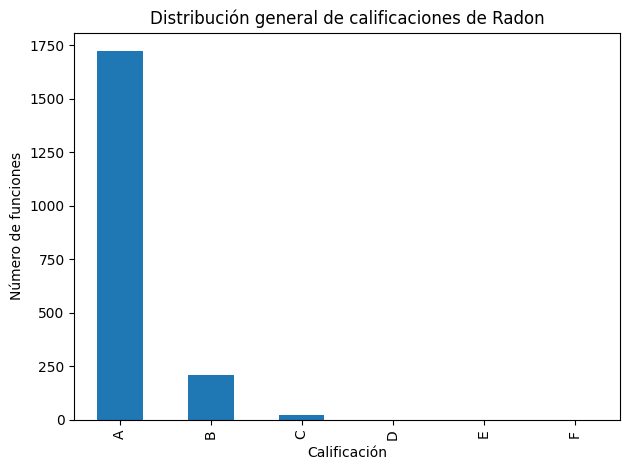

In [38]:
plt.figure()
grade_counts.plot.bar()
plt.title("Distribución general de calificaciones de Radon")
plt.xlabel("Calificación")
plt.ylabel("Número de funciones")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_radon_distribucion_calificaciones.png", dpi=150)
plt.show()

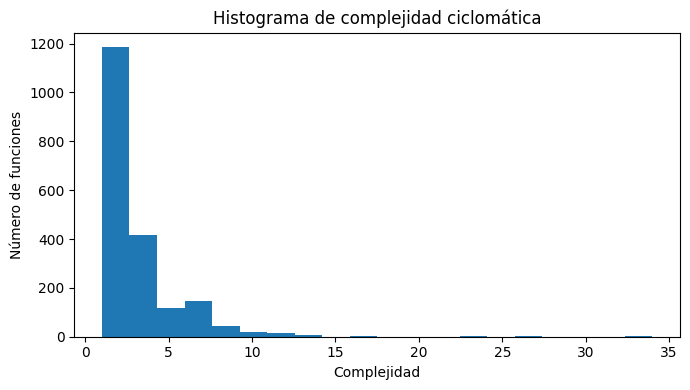

In [40]:
plt.figure(figsize=(7,4))
df_radon["complexity"].dropna().plot.hist(bins=20)
plt.title("Histograma de complejidad ciclomática")
plt.xlabel("Complejidad")
plt.ylabel("Número de funciones")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_radon_hist_complejidad.png", dpi=150)
plt.show()

In [33]:
radon_by_case = (
    df_radon.groupby("case")
    .agg(
        n_functions=("name", "count"),
        max_complexity=("complexity", "max"),
        mean_complexity=("complexity", "mean"),
        max_radon_grade_num=("radon_grade_num", "max"),
        n_closures=("parent", lambda s: s.notna().sum()),
    )
    .reset_index()
)
radon_by_case["max_radon_grade"] = radon_by_case["max_radon_grade_num"].map(RADON_GRADE_ORDER_INV)
radon_by_case.sort_values(["max_radon_grade_num", "max_complexity"], ascending=False)

,case,n_functions,max_complexity,mean_complexity,max_radon_grade_num,n_closures,max_radon_grade
4,python-mini-projects,340,34,3.020588,5,4,E
2,python-algorithms,1474,16,2.957938,3,119,C
1,Analisis-CC-PyCEFR,16,10,4.937500,2,1,B
3,python-beginner-programming-exercises,109,8,2.165138,2,0,B
0,30-Days-Of-Python,22,3,1.181818,1,0,A


In [34]:
radon_top = df_radon.sort_values("complexity", ascending=False).head(50)
radon_top

,case,project,file,file_name,type,name,complexity,radon_grade,radon_grade_num,lineno,endline,col_offset,parent,closure_depth,source_file
1824,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,bot.py,method,on_message,34,E,5,41,171,4,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1638,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,converter.py,function,converter,34,E,5,19,72,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1876,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,biling_system.py,method,bill_area,27,D,4,288,345,4,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1713,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,tic-tac-toe-AI.py,function,win_check,24,D,4,154,168,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1946,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,main.py,function,fetch,17,C,3,15,82,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1850,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,hangman.py,function,play,16,C,3,16,101,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1647,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,Rock-Paper-Scissors Game.py,function,spin,16,C,3,23,58,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1278,python-algorithms,python-algorithms,/home/juan/Documents/Analisis-CC-PyCEFR/python...,is_bst_ordered.py,function,is_bst_ordered,16,C,3,25,51,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
983,python-algorithms,python-algorithms,/home/juan/Documents/Analisis-CC-PyCEFR/python...,avl_tree.py,function,deleteNode,14,C,3,190,222,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...
1714,python-mini-projects,python-mini-projects,/home/juan/Documents/Analisis-CC-PyCEFR/python...,tic-tac-toe-AI.py,function,CompAI,14,C,3,95,124,0,NaN,0,/home/juan/Documents/Analisis-CC-PyCEFR/data/p...


In [35]:
radon_by_case.to_csv(OUTPUT_DIR / "03_radon_resumen_por_caso.csv", index=False)
radon_top.to_csv(OUTPUT_DIR / "03_radon_funciones_mas_complejas.csv", index=False)